## Задание 6
##Деревья решений и ансамбли на их основе
**Цель работы:** научиться решать задачу классификации методами решающих деревьев и ансамблей на их основе.

Выполним анализ набора данных bank.csv. Набор данных связан с кампаниями прямого маркетинга банковского учреждения. Маркетинговые кампании были основаны на телефонных звонках. Часто требовалось более одного контакта с одним и тем же клиентом, чтобы узнать, будет ли у него подписка на продукт (банковский срочный депозит). Цель классификации – предсказать, подпишется ли клиент на срочный депозит (переменная у). Набор данных включает ледующие атрибуты:

*Данные банковского клиента:*
* age – возраст (числовой)
* job – тип работы (категория: "администратор", "неизвестный", "безработный", "менеджер", "горничная", "предприниматель", "студент", "рабочий", "самозанятый", "пенсионер", "техник", "услуги")
* marital – семейное положение (категория: "женат", "разведен", "холост"; примечание: "разведен" означает разведенный или овдовевший)
* education – образование (категория: "неизвестно", "среднее", "начальное",
"высшее")
* default – просрочен ли кредит? (двоичный код: "да", "нет")
* balance – среднегодовой баланс в евро (числовой)
* housing – есть ссуда на жилье? (двоичные значения: "да", "нет")
* loan – есть ссуда на личные нужды? (двоичные значения: "да", "нет")

*Последний контакт в рамках текущей кампании:*
* contact – тип связи с контактом (категория: "неизвестно", "телефон", "сотовый")
* day – последний день контакта в месяце (числовой)
* month – месяц последнего контакта в году (категория: "январь", "февраль",
"март", ... , "ноябрь", "декабрь")
* duration – продолжительность последнего контакта в секундах (числовая)

*Другие атрибуты:*
* campaign – количество контактов, осуществленных в ходе этой кампании и для
данного клиента (числовой, включает последний контакт)
* pdays – количество дней, прошедших с момента последнего контакта с клиентом в рамках предыдущей кампании (числовой, -1 означает, что ранее с клиентом не связывались)
* previous количество контактов, осуществленных до этой кампании и для данного клиента (числовой)
* poutcome – результат предыдущей маркетинговой кампании (категория: "неизвестно", "другое", "неудача", "успех")

*Выходная переменная (целевая):*
* у – клиент подпишется на срочный депозит? (двоичный код: "да", "нет")

## 1. Импорт необходимых библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

## 2. Загрузка и первичный анализ данных

In [4]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('bank.csv', sep=';')

print("="*50)
print("ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ")
print("="*50)
print(f"Размерность данных (shape): {df.shape}")
print(f"\nПервые 5 строк (head):\n{df.head()}")
print(f"\nСтатистика числовых признаков (describe):\n{df.describe()}")
print(f"\nИнформация о данных (info):")
df.info()


Saving bank.csv to bank (1).csv
ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
Размерность данных (shape): (4521, 17)

Первые 5 строк (head):
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknow

## 3. Предобработка данных

In [6]:
#целевая - y
y = df['y'].map({'no': 0, 'yes': 1})  # Кодируем yes=1, no=0

# Признаки (X) - исключаем целевую переменную
X = df.drop('y', axis=1)

# Определяем категориальные и числовые столбцы
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\n" + "="*50)
print("ПРЕДОБРАБОТКА ДАННЫХ")
print("="*50)
print(f"Категориальные признаки: {categorical_cols}")
print(f"Числовые признаки: {numerical_cols}")

# 3.1 Кодирование категориальных признаков
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"Признак '{col}' закодирован.")

# 3.2 Нормализация числовых признаков
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
print("Числовые признаки нормализованы (StandardScaler).")

# Проверка после предобработки
print("\nПервые 5 строк после предобработки:")
print(X.head())


ПРЕДОБРАБОТКА ДАННЫХ
Категориальные признаки: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Числовые признаки: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Признак 'job' закодирован.
Признак 'marital' закодирован.
Признак 'education' закодирован.
Признак 'default' закодирован.
Признак 'housing' закодирован.
Признак 'loan' закодирован.
Признак 'contact' закодирован.
Признак 'month' закодирован.
Признак 'poutcome' закодирован.
Числовые признаки нормализованы (StandardScaler).

Первые 5 строк после предобработки:
        age  job  marital  education  default   balance  housing  loan  \
0 -1.056270   10        1          0        0  0.121072        0     0   
1 -0.772583    7        1          1        0  1.118644        1     1   
2 -0.583458    4        2          2        0 -0.024144        1     0   
3 -1.056270    4        1          2        0  0.017726        1     1   
4  1.686036    1        1          1   

## 4. Разделение данных на обучающую и тестовую выборки

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n" + "="*50)
print("РАЗДЕЛЕНИЕ ДАННЫХ")
print("="*50)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Распределение классов в train:\n{y_train.value_counts()}")
print(f"Распределение классов в test:\n{y_test.value_counts()}")


РАЗДЕЛЕНИЕ ДАННЫХ
Размер обучающей выборки: (3616, 16)
Размер тестовой выборки: (905, 16)
Распределение классов в train:
y
0    3199
1     417
Name: count, dtype: int64
Распределение классов в test:
y
0    801
1    104
Name: count, dtype: int64


## 5. Построение и оценка базового дерева решений


НАСТРОЙКА ГИПЕРПАРАМЕТРОВ
Точность настроенного дерева (max_depth=5) на тесте: 0.8895


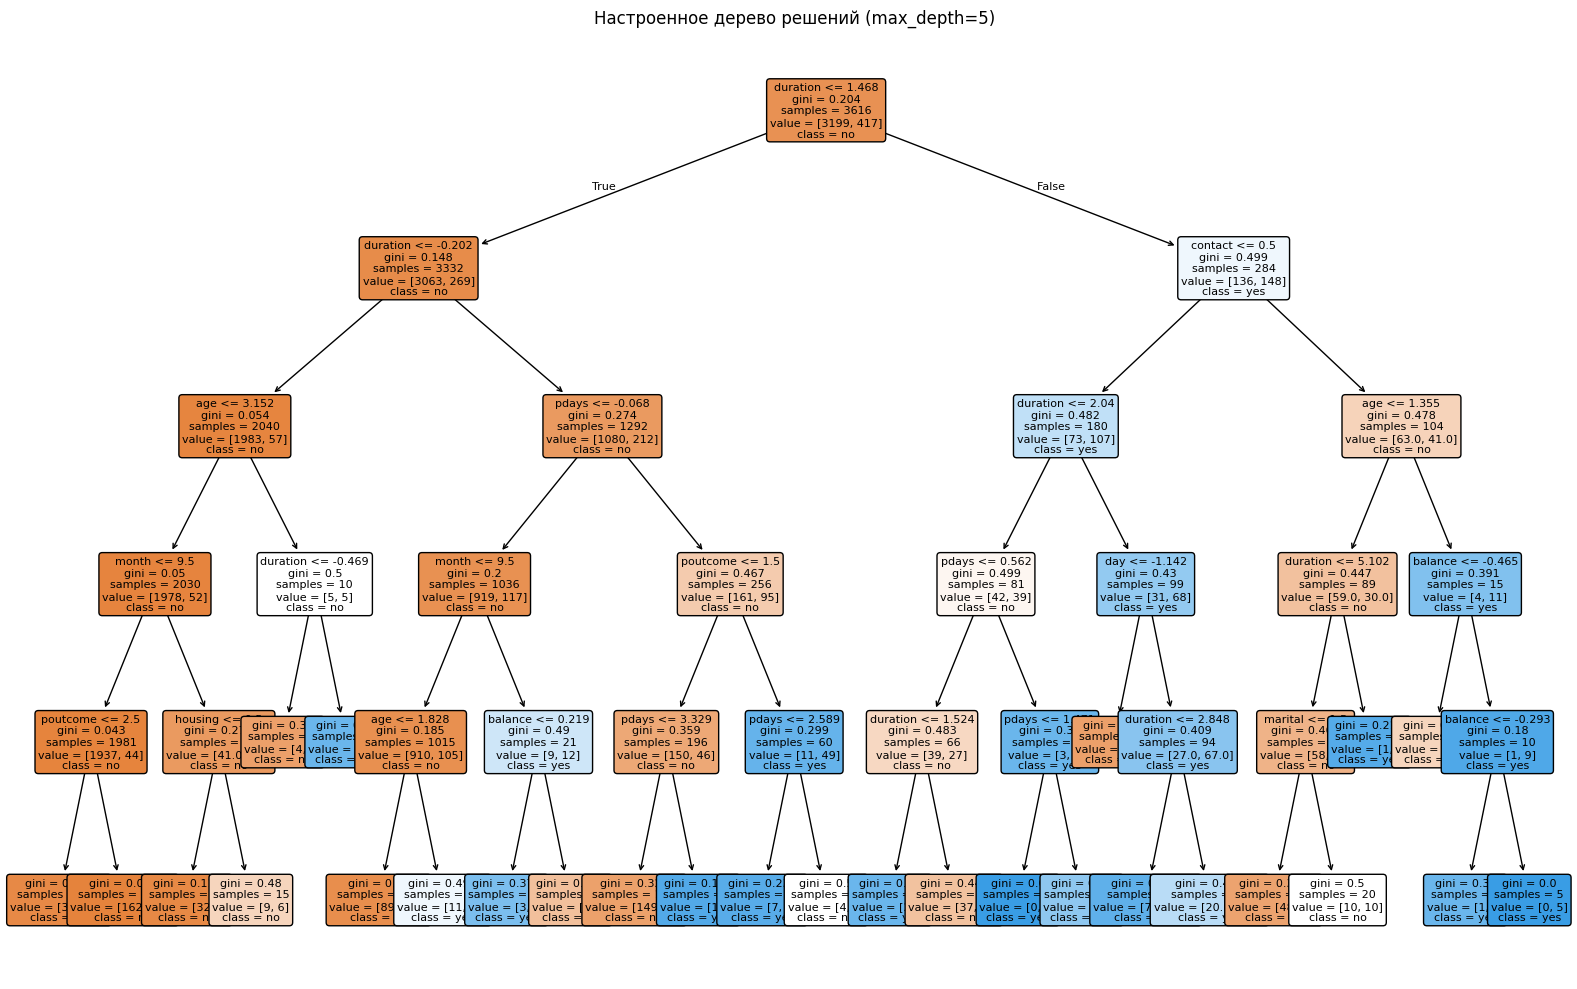

In [9]:
print("\n" + "="*50)
print("НАСТРОЙКА ГИПЕРПАРАМЕТРОВ")
print("="*50)
tuned_dt = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42)
tuned_dt.fit(X_train, y_train)
y_pred_tuned = tuned_dt.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Точность настроенного дерева (max_depth=5) на тесте: {accuracy_tuned:.4f}")

# Визуализация настроенного дерева
plt.figure(figsize=(16, 10))
plot_tree(tuned_dt,
          filled=True,
          feature_names=X.columns.tolist(),
          class_names=['no', 'yes'],
          rounded=True,
          fontsize=8)
plt.title("Настроенное дерево решений (max_depth=5)")
plt.tight_layout()
plt.show()

## 7. Случайный лес


СЛУЧАЙНЫЙ ЛЕС
Точность Random Forest на тесте: 0.8884

Отчет о классификации (Случайный лес):
              precision    recall  f1-score   support

          no       0.91      0.97      0.94       801
         yes       0.53      0.30      0.38       104

    accuracy                           0.89       905
   macro avg       0.72      0.63      0.66       905
weighted avg       0.87      0.89      0.87       905



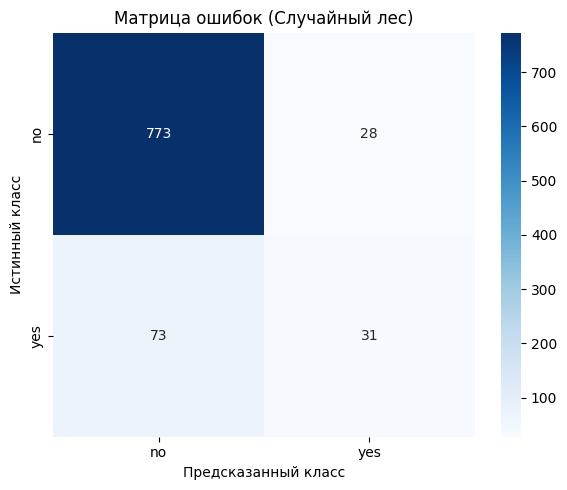

In [10]:
print("\n" + "="*50)
print("СЛУЧАЙНЫЙ ЛЕС")
print("="*50)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Точность Random Forest на тесте: {accuracy_rf:.4f}")
print("\nОтчет о классификации (Случайный лес):")
print(classification_report(y_test, y_pred_rf, target_names=['no', 'yes']))

# Матрица ошибок для Random Forest
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
plt.title('Матрица ошибок (Случайный лес)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

## 8. Подбор гиперпараметров для Случайного леса

In [11]:
print("\n" + "="*50)
print("ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ СЛУЧАЙНОГО ЛЕСА")
print("="*50)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность при кросс-валидации: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred_best_rf)
print(f"Точность улучшенной модели случайного леса на тестовой выборке: {best_accuracy:.4f}")


ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ СЛУЧАЙНОГО ЛЕСА
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Лучшая точность при кросс-валидации: 0.9010
Точность улучшенной модели случайного леса на тестовой выборке: 0.8884


## 9. Сравнение всех моделей


СРАВНЕНИЕ МОДЕЛЕЙ
                         Train Accuracy  Test Accuracy
Base Decision Tree             1.000000       0.857459
Tuned Decision Tree            0.918971       0.889503
Random Forest (default)        1.000000       0.888398
Random Forest (tuned)          0.988108       0.888398


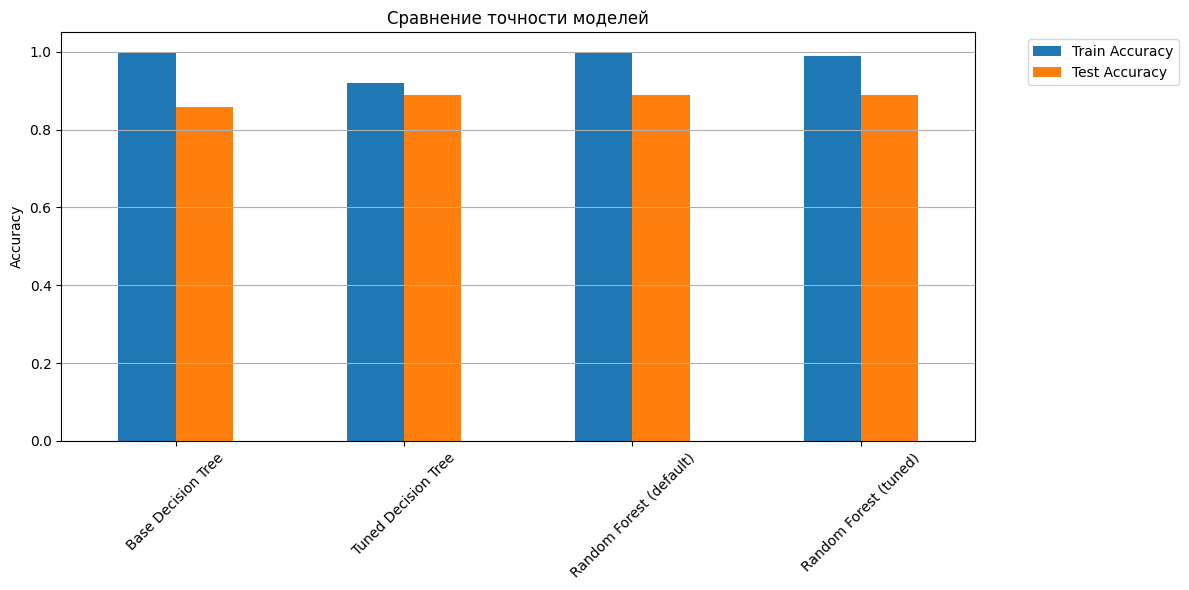

In [12]:
print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*50)
models = {
    'Base Decision Tree': base_dt,
    'Tuned Decision Tree': tuned_dt,
    'Random Forest (default)': rf,
    'Random Forest (tuned)': best_rf
}

results = {}
for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = {'Train Accuracy': train_acc, 'Test Accuracy': test_acc}

results_df = pd.DataFrame(results).T
print(results_df)

# Визуализация сравнения моделей
fig, ax = plt.subplots(figsize=(12, 6))
results_df[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', ax=ax)
ax.set_title("Сравнение точности моделей")
ax.set_ylabel("Accuracy")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

## 10. Анализ важности признаков для лучшей модели


ВАЖНОСТЬ ПРИЗНАКОВ (ЛУЧШАЯ МОДЕЛЬ СЛУЧАЙНОГО ЛЕСА)


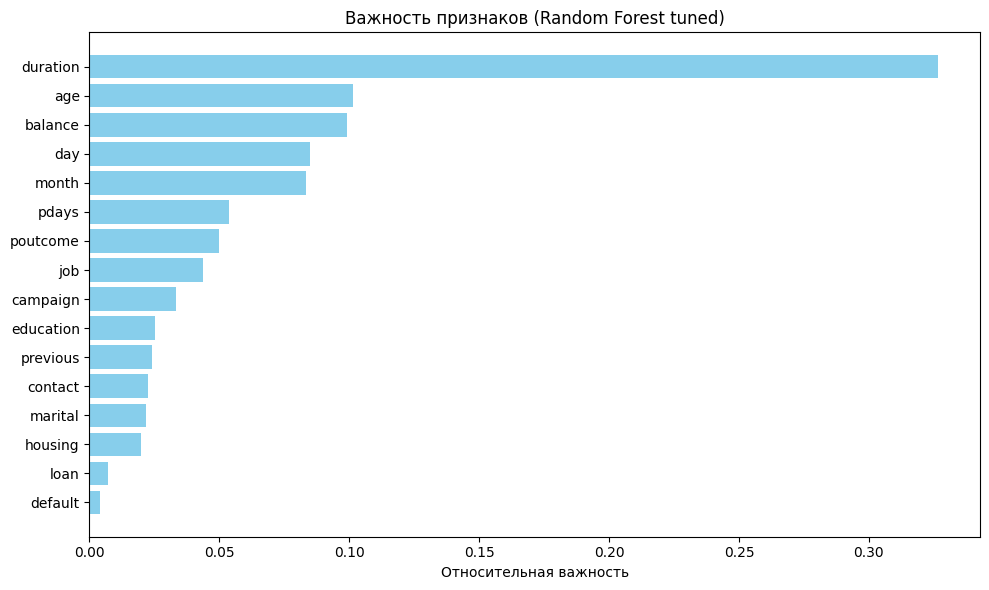

Топ-5 самых важных признаков:
1. duration: 0.3265
2. age: 0.1013
3. balance: 0.0989
4. day: 0.0849
5. month: 0.0835


In [13]:
print("\n" + "="*50)
print("ВАЖНОСТЬ ПРИЗНАКОВ (ЛУЧШАЯ МОДЕЛЬ СЛУЧАЙНОГО ЛЕСА)")
print("="*50)
feature_importances = best_rf.feature_importances_
features = X.columns.tolist()

# Сортируем по убыванию важности
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Random Forest tuned)")
bars = plt.barh(range(len(indices)), feature_importances[indices], color='skyblue')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.gca().invert_yaxis()
plt.xlabel("Относительная важность")
plt.tight_layout()
plt.show()

# Вывод топ-5 самых важных признаков
print("Топ-5 самых важных признаков:")
for i in range(5):
    print(f"{i+1}. {features[indices[i]]}: {feature_importances[indices[i]]:.4f}")